In [70]:
from transformers import Owlv2Processor, Owlv2ForObjectDetection

processor = Owlv2Processor.from_pretrained("google/owlv2-base-patch16-ensemble")
model = Owlv2ForObjectDetection.from_pretrained("google/owlv2-base-patch16-ensemble").to("cuda")

In [71]:
from PIL import Image
import requests
import glob
import time


In [72]:
import torch
import numpy as np
import os
from transformers.utils.constants import OPENAI_CLIP_MEAN, OPENAI_CLIP_STD
from PIL import ImageDraw, ImageFont, Image
from scipy.special import expit as sigmoid
import matplotlib.pyplot as plt

def get_preprocessed_image(pixel_values):
    pixel_values = pixel_values.squeeze().cpu().numpy()
    unnormalized_image = (pixel_values * np.array(OPENAI_CLIP_STD)[:, None, None]) + np.array(OPENAI_CLIP_MEAN)[:, None, None]
    unnormalized_image = (unnormalized_image * 255).astype(np.uint8)
    unnormalized_image = np.moveaxis(unnormalized_image, 0, -1)
    unnormalized_image = Image.fromarray(unnormalized_image)
    return unnormalized_image


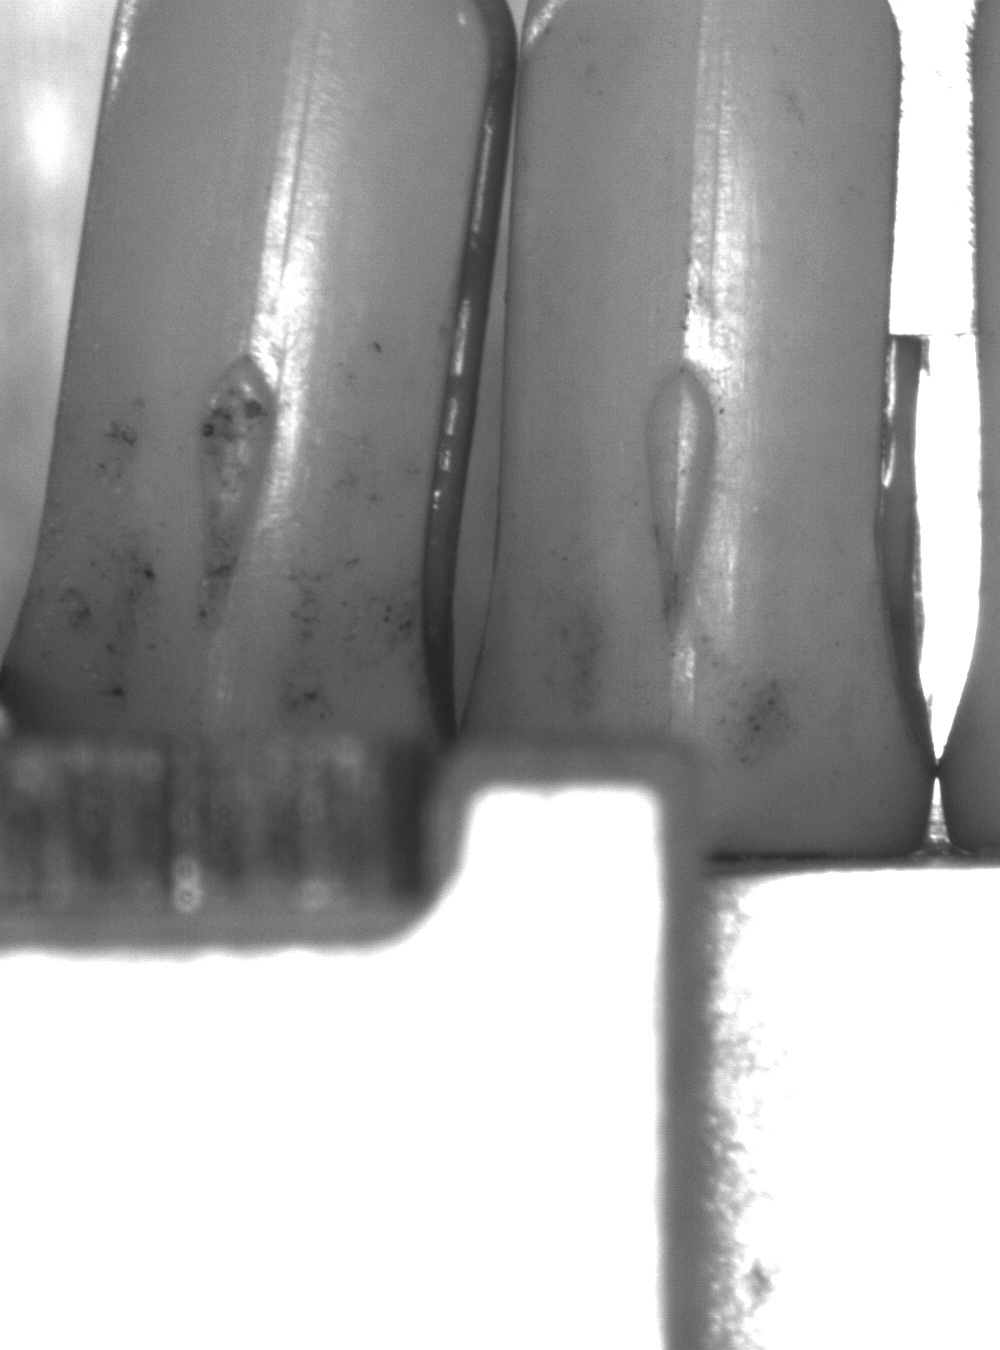

In [73]:
body_image_path = r"E:\Hachix\data\mounting_nock\nock\20251212162453_C1.jpeg"
image = Image.open(body_image_path)
image

In [74]:
import shutil

In [105]:
# Body
BODY_DIR = r"E:\Hachix\data\mounting_nock\nock"

files = glob.glob(f"{BODY_DIR}/*.jpeg")
save_dir = "./results/"
os.makedirs(save_dir, exist_ok=True)

for file in files:
    start = time.perf_counter()
    body_image_path = file
    # body_image_path = "../data/hole/outermost_periphery_11.jpg"

    image = Image.open(body_image_path).convert("RGB")#.crop((1300, 1020, 2919,1989))
    texts = [['nock bump']]
    inputs = processor(text=texts, images=image, return_tensors="pt").to("cuda")
    # for k,v in inputs.items():
    #   print(k,v.shape)
    
    with torch.no_grad():
      outputs = model(**inputs)
    
    unnormalized_image = get_preprocessed_image(inputs.pixel_values)
    
    # Convert outputs (bounding boxes and class logits) to COCO API
    target_sizes = torch.Tensor([unnormalized_image.size[::-1]])
    results = processor.post_process_object_detection(outputs=outputs, target_sizes=target_sizes, threshold=0.16)
    i = 0  # Retrieve predictions for the first image for the corresponding text queries
    text = texts[i]
    boxes, scores, labels = results[i]["boxes"], results[i]["scores"], results[i]["labels"]
    for box, score, label in zip(boxes, scores, labels):
        box = [round(i, 2) for i in box.tolist()]
        # print(f"Detected {text[label]} with confidence {round(score.item(), 3)} at location {box}")
    
    visualized_image = unnormalized_image.copy()
    
    draw = ImageDraw.Draw(visualized_image)
    font = ImageFont.load_default(20) 
    color = (255, 0, 0)
    ng = []
    for box, score, label in zip(boxes, scores, labels):
        
        box = [round(i, 2) for i in box.tolist()]
        x1, y1, x2, y2 = tuple(box)
        ## box must be in range from y 210 to 470
        if not (210 < y1 < 470 and 210 < y2 < 470):
            continue
        ng.append(box)
        draw.rectangle(xy=((x1, y1), (x2, y2)), outline=color)
        draw.text((x1, y1), f"{text[label]}: {score:.2f}", fill=color, font=font)
    labels_dir = "./results/labels"
    images_dir = "./results/images"
    os.makedirs(labels_dir, exist_ok=True)
    os.makedirs(images_dir, exist_ok=True)
    W_orig, H_orig = image.size
    W_proc, H_proc = unnormalized_image.size
    scale_x = W_proc / W_orig
    scale_y = H_proc / H_orig
    scale = min(scale_x, scale_y)
    new_w = int(W_orig * scale)
    new_h = int(H_orig * scale)

    print(f"Original size: {W_orig}x{H_orig}, Processed size: {W_proc}x{H_proc}, New size: {new_w}x{new_h}")
    if ng:
        # copy to images and write txt label format yolo normalized to labels
        txt_save_path = os.path.join(labels_dir, os.path.basename(body_image_path).replace(".jpeg", ".txt"))
        with open(txt_save_path, "w") as f:
            for box in ng:
                x1, y1, x2, y2 = box

                x_center = (x1 + x2) / 2 / new_w
                y_center = (y1 + y2) / 2 / new_h
                width = (x2 - x1) / new_w
                height = (y2 - y1) / new_h
                f.write(f"0 {x_center} {y_center} {width} {height}\n")
        shutil.copy(body_image_path, os.path.join(images_dir, os.path.basename(body_image_path)))
    else:
        continue

    # visualized_image = visualized_image.crop((0,0, 960, int(960/image.size[0]*image.size[1])))
    visualized_image.save(os.path.join(save_dir, os.path.basename(body_image_path)), "JPEG", quality=90)
    end = time.perf_counter()
    print(f"Processed {os.path.basename(body_image_path)} in {end - start:.4f} seconds.")



Original size: 1000x1350, Processed size: 960x960, New size: 711x960
Processed 20251212164400_C1.jpeg in 0.7076 seconds.
Original size: 1000x1350, Processed size: 960x960, New size: 711x960
Processed 20251212164344_C1.jpeg in 0.5394 seconds.
Original size: 1000x1350, Processed size: 960x960, New size: 711x960
Original size: 1000x1350, Processed size: 960x960, New size: 711x960
Processed 20251212164321_C1.jpeg in 0.5526 seconds.
Original size: 1000x1350, Processed size: 960x960, New size: 711x960
Processed 20251212164308_C1.jpeg in 0.5365 seconds.
Original size: 1000x1350, Processed size: 960x960, New size: 711x960
Processed 20251212164300_C1.jpeg in 3.7635 seconds.
Original size: 1000x1350, Processed size: 960x960, New size: 711x960
Processed 20251212164252_C1.jpeg in 0.5924 seconds.
Original size: 1000x1350, Processed size: 960x960, New size: 711x960
Original size: 1000x1350, Processed size: 960x960, New size: 711x960
Processed 20251212164237_C1.jpeg in 0.6606 seconds.
Original size: 

In [106]:
# split images + labels to train and val to train yolo
dataset_path = "./dataset"
output_train_dir = os.path.join(dataset_path, "images/train")
output_val_dir = os.path.join(dataset_path, "images/val")
output_labels_train_dir = os.path.join(dataset_path, "labels/train")
output_labels_val_dir = os.path.join(dataset_path, "labels/val")
os.makedirs(output_train_dir, exist_ok=True)
os.makedirs(output_val_dir, exist_ok=True)
os.makedirs(output_labels_train_dir, exist_ok=True)
os.makedirs(output_labels_val_dir, exist_ok=True)
SEED = 42
import random
from sklearn.model_selection import train_test_split
random.seed(SEED)

all_images = glob.glob(os.path.join(images_dir, "*.jpeg"))
train_images, val_images = train_test_split(all_images, test_size=0.2, random_state=SEED)
for train_image in train_images:
    shutil.copy(train_image, output_train_dir)
    label_path = os.path.join(labels_dir, os.path.basename(train_image).replace(".jpeg", ".txt"))
    shutil.copy(label_path, output_labels_train_dir)
for val_image in val_images:
    shutil.copy(val_image, output_val_dir)
    label_path = os.path.join(labels_dir, os.path.basename(val_image).replace(".jpeg", ".txt"))
    shutil.copy(label_path, output_labels_val_dir)



In [107]:
# create file data.yaml
with open(os.path.join(dataset_path, "data.yaml"), "w") as f:
    f.write(f"""names:
- key
nc: 1
train: D://Study//repos//ai-collection//code//auto_label_yolo//dataset//images//train
val: D://Study//repos//ai-collection//code//auto_label_yolo//dataset//images//val
""")

In [108]:
# plot 1 example from labels_dir and images_dir
example_image_path = glob.glob(os.path.join(images_dir, "*.jpeg"))[0]
example_label_path = os.path.join(labels_dir, os.path.basename(example_image_path).replace(".jpeg", ".txt"))
example_image = Image.open(example_image_path).convert("RGB")
draw = ImageDraw.Draw(example_image)
font = ImageFont.load_default(20)
example_shape = example_image.size
with open(example_label_path, "r") as f:
    lines = f.readlines()
    for line in lines:
        class_id, x_center, y_center, width, height = map(float, line.strip().split())
        x_center *= example_shape[0]
        y_center *= example_shape[1]
        width *= example_shape[0]
        height *= example_shape[1]
        x1 = x_center - width / 2
        y1 = y_center - height / 2
        x2 = x_center + width / 2
        y2 = y_center + height / 2
        draw.rectangle(xy=((x1, y1), (x2, y2)), outline=(255,0,0))
        draw.text((x1, y1), f"class {int(class_id)}", fill=(255,0,0), font=font)
example_image.show()

In [1]:
import sys
import os
import json
import argparse
import easydict
from ecos_core.yolo8.yolo8 import Model

opt = "./opt_yolo.json"
weight_path = r"D:\Hachix\project\ECOS_AI-dev\projects\sample_autodistill\yolov8s.pt"
with open(opt, "r") as f:
    args = easydict.EasyDict(json.load(f))
yolo_model = Model(args)
yolo_model.build_model(weight_path)
yolo_model.fit()

Using custom model weights: D:\Hachix\project\ECOS_AI-dev\projects\sample_autodistill\yolov8s.pt
Loading model weights from file: D:\Hachix\project\ECOS_AI-dev\projects\sample_autodistill\yolov8s.pt
New https://pypi.org/project/ultralytics/8.3.237 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.223  Python-3.10.4 torch-1.13.1+cu117 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
WARNING Upgrade to torch>=2.0.0 for deterministic training.
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D://Study//repos//ai-collection//code//auto_label_yolo//dataset//data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscrip

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001943D4408B0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480